Importar Librerias

In [2]:
# Librerías para manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

# Métricas
from sklearn.metrics import confusion_matrix, classification_report

# Red neuronal
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

In [3]:
import os

print("Directorio actual:", os.getcwd())
print("Archivos disponibles:", os.listdir())


Directorio actual: /content
Archivos disponibles: ['.config', 'sample_data']


Cargar Dataset

In [37]:
url = "https://raw.githubusercontent.com/CDOM24/Taller-ANN/main/riesgo.csv"

df = pd.read_csv(url, sep=";")

df.head()

,Customer_ID,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,CUS_0x1000,Alistair Barrf,"17,375",913-74-1218,Lawyer,"30625,94","2706,161667",6,5,27,...,Bad,"1562,91","33,47754647","10,45833333",Yes,"42,94109042","158,5497352",High_spent_Medium_value_payments,"335,3753411",0
1,CUS_0x1009,Arunah,"25,75",063-67-6938,Mechanic,"52312,68","4250,39",6,5,17,...,Standard,"202,68","29,83998399","30,71428571",Yes,"108,3664671","146,6793779",High_spent_Medium_value_payments,"428,743155",1
2,CUS_0x100b,Shirboni,"18,5",238-62-0395,Media_Manager,"113781,39","9549,7825",1,4,1,...,Good,"1030,2","34,84144912","15,57142857",No,0,"505,3865264",High_spent_Large_value_payments,"781,2297763",0
3,CUS_0x1011,Schneyerh,"43,875",793-05-8223,Doctor,"58918,47","5208,8725",3,3,17,...,Standard,"473,14","27,65589672","15,54166667",Yes,"123,4349388","311,0609143",Low_spent_Medium_value_payments,"332,6428375",1
4,CUS_0x1013,Cameront,"43,75",930-49-9615,Mechanic,"98620,98","7962,415",3,3,6,...,Good,"1233,51","31,93394005","17,53571429",No,"228,0180837","355,4424076",High_spent_Medium_value_payments,"472,7810087",1


Información del dataset

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12500 entries, 0 to 12499
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Customer_ID               12500 non-null  object
 1   Name                      12500 non-null  object
 2   Age                       12500 non-null  object
 3   SSN                       12500 non-null  object
 4   Occupation                12500 non-null  object
 5   Annual_Income             12500 non-null  object
 6   Monthly_Inhand_Salary     12500 non-null  object
 7   Num_Bank_Accounts         12500 non-null  object
 8   Num_Credit_Card           12500 non-null  object
 9   Interest_Rate             12500 non-null  int64 
 10  Num_of_Loan               12500 non-null  int64 
 11  Type_of_Loan              11074 non-null  object
 12  Delay_from_due_date       12500 non-null  object
 13  Num_of_Delayed_Payment    12500 non-null  object
 14  Changed_Credit_Limit  

Distribución del Credit Score

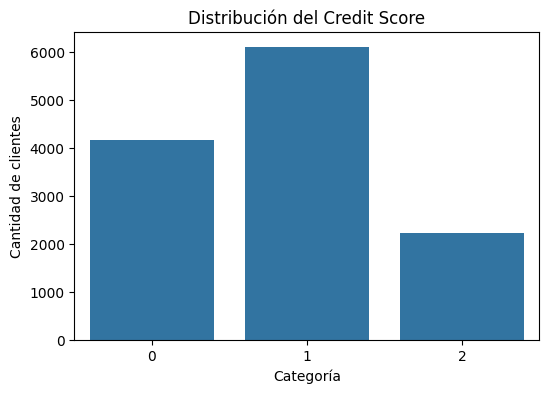

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x="Credit_Score", data=df)

plt.title("Distribución del Credit Score")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de clientes")

plt.show()

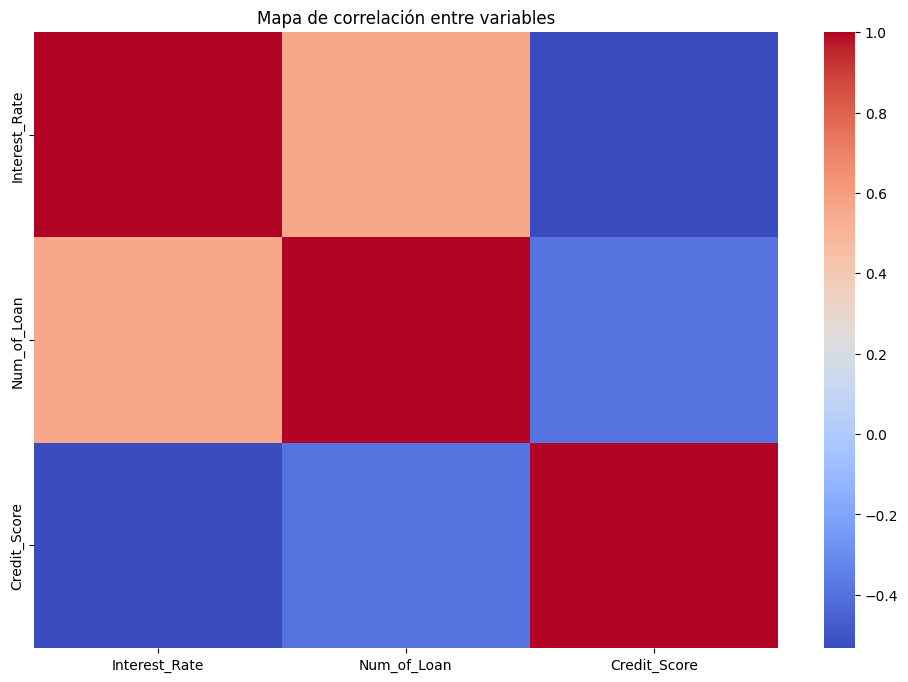

In [12]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")

plt.title("Mapa de correlación entre variables")

plt.show()

In [13]:
df = df.drop(columns=["Customer_ID", "Name", "SSN"])

In [14]:
X = df.drop("Credit_Score", axis=1)
y = df["Credit_Score"]

In [15]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(include=["int64","float64"]).columns

print("Categóricas:", categorical_cols)
print("Numéricas:", numerical_cols)

Categóricas: Index(['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance'],
      dtype='object')
Numéricas: Index(['Interest_Rate', 'Num_of_Loan'], dtype='object')


In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [19]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=50)

X_train = svd.fit_transform(X_train)
X_test = svd.transform(X_test)

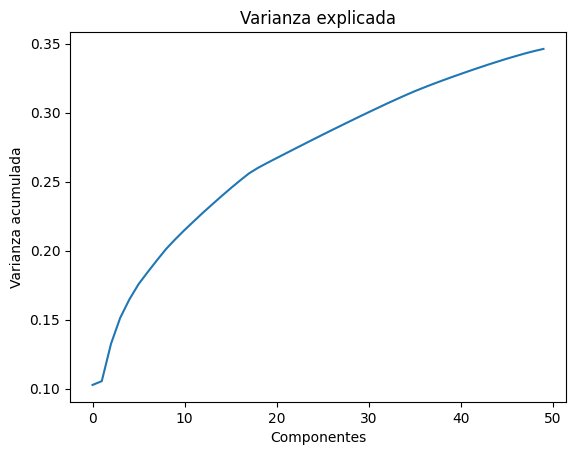

In [20]:


plt.plot(np.cumsum(svd.explained_variance_ratio_))

plt.xlabel("Componentes")
plt.ylabel("Varianza acumulada")
plt.title("Varianza explicada")

plt.show()

In [21]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [22]:
model = Sequential()

model.add(Dense(64, activation="relu", input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation="relu"))

model.add(Dense(3, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [24]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5896 - loss: 0.8630 - val_accuracy: 0.7040 - val_loss: 0.6990
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7128 - loss: 0.6789 - val_accuracy: 0.7050 - val_loss: 0.6952
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7251 - loss: 0.6649 - val_accuracy: 0.7040 - val_loss: 0.6871
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7263 - loss: 0.6418 - val_accuracy: 0.7070 - val_loss: 0.6834
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7354 - loss: 0.6258 - val_accuracy: 0.7055 - val_loss: 0.6866
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7411 - loss: 0.6146 - val_accuracy: 0.7125 - val_loss: 0.6704
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7312 - loss: 0.6291 - val_accuracy: 0.7115 - val_loss: 0.6731
Epoch 8/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7437 - loss: 0.6070 - val_accuracy: 0.

In [25]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6752 - loss: 0.7948
Accuracy: 0.6751999855041504


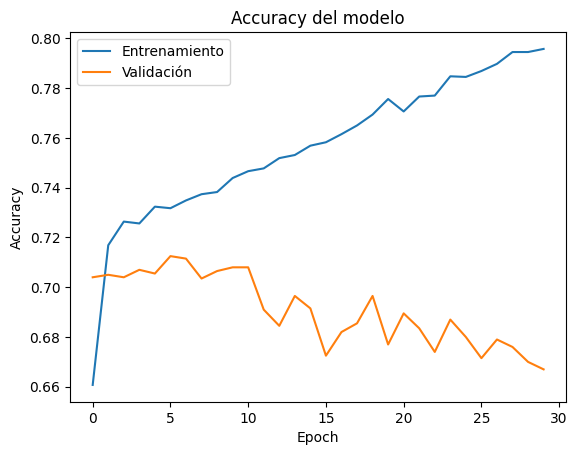

In [26]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Accuracy del modelo")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Entrenamiento","Validación"])

plt.show()

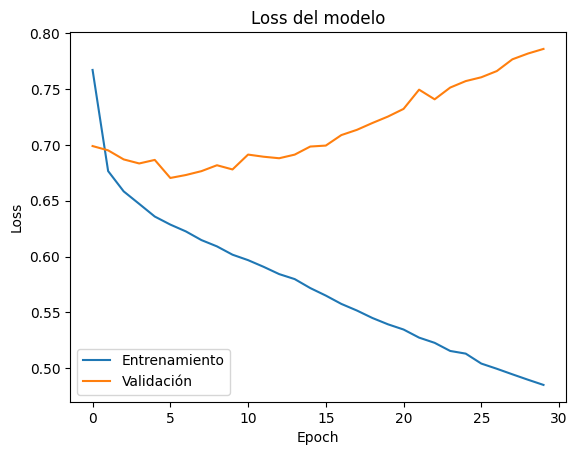

In [27]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Loss del modelo")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Entrenamiento","Validación"])

plt.show()

In [28]:
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


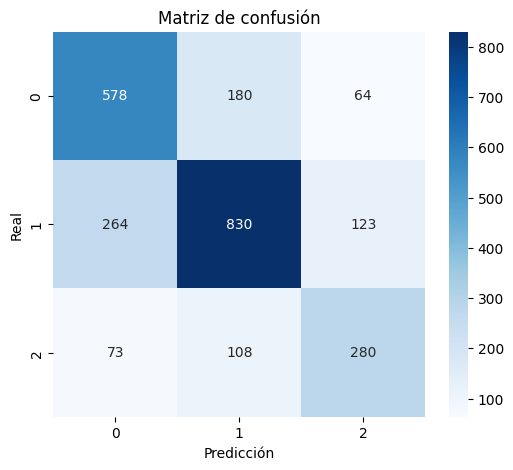

In [29]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

In [30]:
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.63      0.70      0.67       822
           1       0.74      0.68      0.71      1217
           2       0.60      0.61      0.60       461

    accuracy                           0.68      2500
   macro avg       0.66      0.66      0.66      2500
weighted avg       0.68      0.68      0.68      2500



In [31]:
model.save("modelo_credit_score.keras")

In [32]:
import os

os.listdir()

['.config', 'modelo_credit_score.keras', 'sample_data']

In [35]:
model.save("modelo_credit_score.keras")